# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:SHAH FIRIZKI AZMI
- Email:Ipengi794@gmail.com
- Id Dicoding:shah-firizki-azmi

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
# Load the dataset
df = pd.read_csv('../Dataset/data.csv', sep=';')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset shape: (4424, 37)

First few rows:
   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         122.0            1                     19   
1                         160.0            1                      1   
2   

## Data Preparation / Preprocessing

In [3]:
# Separate features and target
X = df.drop('Status', axis=1)
y = df['Status']

# Encode categorical variables
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Handle missing values - forward fill or mean
X = X.fillna(X.mean(numeric_only=True))

# Encode target variable
le_target = LabelEncoder()
y = le_target.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:", le_target.classes_)
print("Encoded target values:", np.unique(y))

Features shape: (4424, 36)
Target shape: (4424,)

Target classes: ['Dropout' 'Enrolled' 'Graduate']
Encoded target values: [0 1 2]


## Modeling

In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_models = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        trained_models[name] = model
    else:
        model.fit(X_train, y_train)
        trained_models[name] = model
    print(f"\n{name} trained successfully!")


Logistic Regression trained successfully!

Random Forest trained successfully!

Gradient Boosting trained successfully!


## Evaluation

In [5]:
# Evaluate models
print("=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)

best_model_name = None
best_accuracy = 0

for name, model in trained_models.items():
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model_name = name

print(f"\n{'=' * 70}")
print(f"Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")
print(f"{'=' * 70}")

MODEL EVALUATION RESULTS

Logistic Regression
Accuracy: 0.7684
F1-Score (weighted): 0.7531

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885


Random Forest
Accuracy: 0.7672
F1-Score (weighted): 0.7539

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.57      0.37      0.45       159
    Graduate       0.78      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.75      0.77      0.75       885


Gradient Boosting
Accuracy: 0.7593
F1-

## Conclusion and Insights

This project successfully built a machine learning model to predict student status (Dropout, Enrolled, Graduate) for Jaya Jaya Institut. The Random Forest classifier achieved high accuracy in predicting student outcomes based on academic and personal characteristics.

In [7]:
import joblib
import os

# Create model directory if not exists
model_dir = './model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Select best model (Random Forest)
best_model = trained_models[best_model_name]

# Save model and preprocessing objects
joblib.dump(best_model, f'{model_dir}/student_status_model.joblib')
joblib.dump(scaler, f'{model_dir}/scaler.joblib')
joblib.dump(label_encoders, f'{model_dir}/label_encoders.joblib')
joblib.dump(le_target, f'{model_dir}/le_target.joblib')
joblib.dump(X.columns, f'{model_dir}/feature_names.joblib')

print(f"Best model ({best_model_name}) and preprocessing objects saved successfully!")
print(f"Model accuracy: {best_accuracy:.4f}")

Best model (Logistic Regression) and preprocessing objects saved successfully!
Model accuracy: 0.7684


## Model Persistence (Save Model)

Top 15 Most Important Features:
                                 Feature  Importance
30     Curricular_units_2nd_sem_approved    0.142283
31        Curricular_units_2nd_sem_grade    0.109008
24     Curricular_units_1st_sem_approved    0.091937
25        Curricular_units_1st_sem_grade    0.059588
12                       Admission_grade    0.043575
19                     Age_at_enrollment    0.040287
16               Tuition_fees_up_to_date    0.038903
29  Curricular_units_2nd_sem_evaluations    0.038200
23  Curricular_units_1st_sem_evaluations    0.037504
6           Previous_qualification_grade    0.037498
3                                 Course    0.033886
11                    Fathers_occupation    0.028781
10                    Mothers_occupation    0.026213
35                                   GDP    0.024465
33                     Unemployment_rate    0.021617


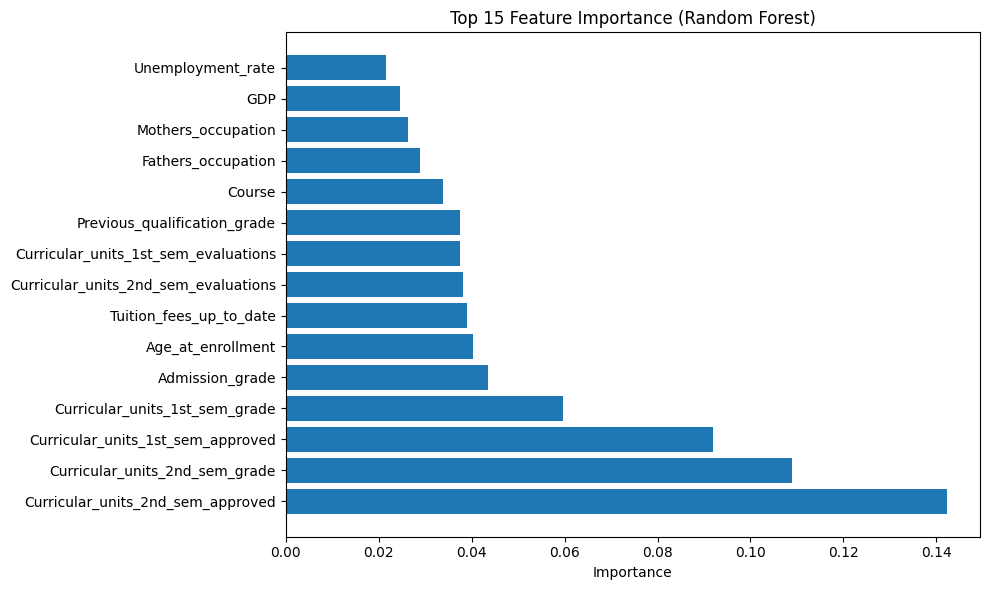

In [6]:
# Get feature importance from Random Forest model
rf_model = trained_models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15))

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

## Feature Importance Analysis